Comenzamos definiendo las variables lingüisticas:
    - Presión sistólica (PS)
    - Presión diastólica (PD)
Que podrán tomar valores crisp dentro del universo de discurso.
    Ej: PS = 128 mmHg.
A su vez, estas variables toman los siguientes valores lingüisticos
    - Presión sistólica: normal, elevada, alta hipetensión grado 1, alta hipertensión grado 2 y crisis hipertensa.
    - Presión diastólica: idem.
Luego, cada etiqueta difusa tendrá un conjunto difuso asociado, junto a una función de pertenencia μ(x) que lo define.
Se visualizan en el siguiente cuadro:
| Etiqueta | Conjunto difuso | Función de pertenencia |
| Sistólica normal (SN) | N={(x,μSN​(x)):x∈U} | trap(85,95,115,125) |
| Sistólica elevada (SE)| SE={(x,μSE​(x)):x∈U} | tri(115,125,135) |
| Sistólica hipertensión G1 (SH1) | SH1={(x,μSH1​(x)):x∈U} | tri(125,135,145) |
| Sistólica hipertensión G2 (SH2) | SH2={(x,μSH2​(x)):x∈U} | trap(135,145,175,185) |
| Sistólica crisis hipertensa (SCH) | SCH={(x,μSCH​(x)):x∈U} | S(170,190) |
| Diastólica normal (DN) | DN={(x,μDN​(x)):x∈U} | trap(55,65,75,85) |
| Diastólica hipertensión G1 (DH1) | DH1={(x,μDH1​(x)):x∈U} | tri(75,85,95) |
| Diastólica hipertensión G2 (DH2) | DH2={(x,μDH2​(x)):x∈U} | trap(85,95,115,125) |
| Diastólica crisis hipertensa (DCH) | DCH={(x,μDCH​(x)):x∈U} | S(110,130) |




In [1]:
%pip install -U scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -U scipy

  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl (36.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

In [6]:
# Funciones para la presión sistólica.

ps = np.arange(50, 251, 1)

ps_normal = fuzz.trapmf(ps, [85, 95, 115, 125])
ps_elevada = fuzz.trimf(ps, [115, 125, 135])
ps_grado1 = fuzz.trimf(ps, [125, 135, 145])
ps_grado2 = fuzz.trapmf(ps, [135, 145, 175, 185])
ps_crisis = fuzz.smf(ps, 170, 190)

In [8]:
# Funciones para la presión diastólica.
pd = np.arange(30, 151, 1)

pd_normal = fuzz.trapmf(pd, [55, 65, 75, 85])
pd_grado1 = fuzz.trimf(pd, [75, 85, 95])
pd_grado2 = fuzz.trapmf(pd, [85, 95, 115, 125])
pd_crisis = fuzz.smf(pd, 110, 130)

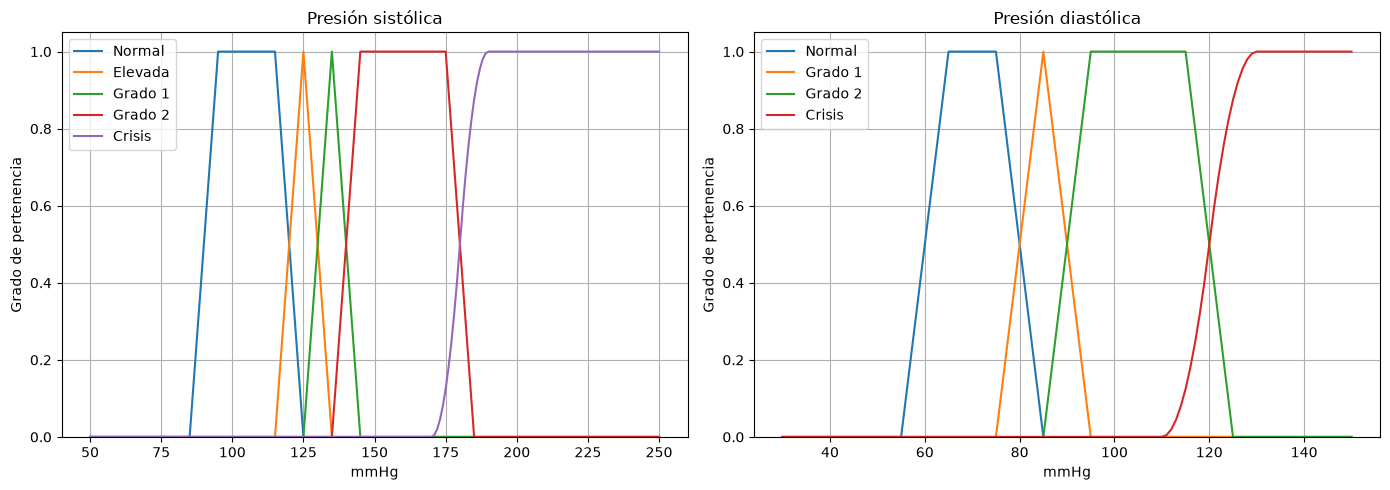

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sistólica
axes[0].plot(ps, ps_normal, label="Normal")
axes[0].plot(ps, ps_elevada, label="Elevada")
axes[0].plot(ps, ps_grado1, label="Grado 1")
axes[0].plot(ps, ps_grado2, label="Grado 2")
axes[0].plot(ps, ps_crisis, label="Crisis")

axes[0].set_title("Presión sistólica")
axes[0].set_xlabel("mmHg")
axes[0].set_ylabel("Grado de pertenencia")
axes[0].set_ylim(0, 1.05)
axes[0].grid()
axes[0].legend()

# Diastólica
axes[1].plot(pd, pd_normal, label="Normal")
axes[1].plot(pd, pd_grado1, label="Grado 1")
axes[1].plot(pd, pd_grado2, label="Grado 2")
axes[1].plot(pd, pd_crisis, label="Crisis")

axes[1].set_title("Presión diastólica")
axes[1].set_xlabel("mmHg")
axes[1].set_ylabel("Grado de pertenencia")
axes[1].set_ylim(0, 1.05)
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

Una vez definidas las funciones podemos pasar a evaluar la condición de un paciente mediante proposiciones.

p = "El paciente tiene presión arterial normal"

Luego, pasando a algebra difusa

IF Presión sistólica normal AND Presión diastólica normal THEN p

Para ejemplificar, armaremos un conjunto de proposiciones sobre un paciente.

Valores del paciente: PS = 128 mmHg y PD = 84 mmHg

a = "El paciente tiene presión arterial normal"
b = "El paciente tiene presión arterial elevada"
c = "El paciente tiene hipertensión grado 1"
d = "El paciente tiene hipertensión grado 2"
e = "El paciente sufre una crisis hipertensa"

In [18]:
import numpy as np
import skfuzzy as fuzz

PS = 128
PD = 84

def fuzzy_and_geometric(mu_q, mu_r):
    """
    AND compensatorio mediante media geométrica.
    """
    return np.sqrt(mu_q * mu_r)


def fuzzy_or_geometric(mu_q, mu_r):
    """
    OR dual de la media geométrica.
    """
    return 1.0 - np.sqrt((1.0 - mu_q) * (1.0 - mu_r))


def evaluar_pertenencia(universo, conjunto_difuso, valor):
    """
    Evalúa un valor concreto dentro de una función de pertenencia.
    """
    return fuzz.interp_membership(
        universo,
        conjunto_difuso,
        valor
    )


# Fuzzificación de la presión sistólica
mu_ps_normal = evaluar_pertenencia(ps, ps_normal, PS)
mu_ps_elevada = evaluar_pertenencia(ps, ps_elevada, PS)
mu_ps_grado1 = evaluar_pertenencia(ps, ps_grado1, PS)
mu_ps_grado2 = evaluar_pertenencia(ps, ps_grado2, PS)
mu_ps_crisis = evaluar_pertenencia(ps, ps_crisis, PS)

# Fuzzificación de la presión diastólica
mu_pd_normal = evaluar_pertenencia(pd, pd_normal, PD)
mu_pd_grado1 = evaluar_pertenencia(pd, pd_grado1, PD)
mu_pd_grado2 = evaluar_pertenencia(pd, pd_grado2, PD)
mu_pd_crisis = evaluar_pertenencia(pd, pd_crisis, PD)

# Evaluación de las proposiciones compuestas
diag = {
    "Presión arterial normal":
        fuzzy_and_geometric(mu_ps_normal, mu_pd_normal),

    "Presión arterial elevada":
        fuzzy_and_geometric(mu_ps_elevada, mu_pd_normal),

    "Hipertensión grado 1":
        fuzzy_or_geometric(mu_ps_grado1, mu_pd_grado1),

    "Hipertensión grado 2":
        fuzzy_or_geometric(mu_ps_grado2, mu_pd_grado2),

    "Crisis hipertensiva":
        fuzzy_or_geometric(mu_ps_crisis, mu_pd_crisis)
}

for diagnostico, grado in diag.items():
    print(f"{diagnostico}: {grado:.3f}")

clasificacion = max(diag, key=diag.get)

print(
    f"\nClasificación principal: {clasificacion}"
    f" ({diag[clasificacion]:.3f})"
)

Presión arterial normal: 0.000
Presión arterial elevada: 0.265
Hipertensión grado 1: 0.735
Hipertensión grado 2: 0.000
Crisis hipertensiva: 0.000

Clasificación principal: Hipertensión grado 1 (0.735)
